**Required viewing**

[Clustering MIT](https://www.youtube.com/watch?v=dyb_cFywuik)

**Clustering**
- Machine learning technique that uses unsupervised learning
- Group unlabelled data into natural clusters
- Clustering is an optimisation problem
- $variability(c) = \sum_{e \in c}distance(mean(c), e)^2$
- Variance is different from variability, you don't divide by n.This is because in clustering big and bad is worse than small and bad. We don't want to average out the difference.
- $dissimilarity(C) = \sum_{c \in C}variability(c)$
- Find C that minimises the dissimilarity
- In order for this not to end up as each point being a cluster, we add a constraint e.g the clusters have to have some minimum distance or contrain the number of clusters


**Hierarchical clustering**
- Start by assigning each item to a cluster so that you have $N$ items, you know have $N$ clusters, each containing one item
- Find the closest (most similar) pair of clusters and merge them inti a single cluster, so now we have one fewer clusters
- Continue until all items are clustered into a single cluster of size $N$ 
- Agglomerative hierarchical cluster
- What do we mean by closest?
- Can get clusters depending on the linkage metric
- **Single linkage**: consider between the distance between one cluster and another to be equal to the shortest distance of any member of one cluster to any member of another cluster
- **Complete Linkage**: consider the distance between one cluster and another cluster as the greatest distance from any member of one cluster to any member of another cluster
- **Average Linkage**: consider the distance between one cluster and another cluster as the average distance from any member of one cluster to any member of the other cluster

|BOS|NY|CHI|DEN|SF|SEA|
|---|---|---|---|---|---|
|0|206|963|1949|3095|2979|
|0|0|802|1771|2934|2815|
|0|0|0|966|1235|1307|
|0|0|0|0|1235|1307|
|0|0|0|0|0|808|
|0|0|0|0|0|0|

**Clusters**
- [BOS, NY] [CHI] [DEN] [SF] [SEA]
- **Single** [BOS, NY, CHI] [DEN] [SF] [SEA]
- **Complete** [BOS, NY] [CHI] [DEN] [SF, SEA]
- **Single** [BOS, NY, CHI] [DEN] [SF, SEA]
- **Complete** [BOS, NY, CHI] [DEN] [SF, SEA]
- **Single** [BOS, NY, CHI, DEN] [SF, SEA]
- **Complete** [BOS, NY, CHI] [DEN, SF, SEA]

**Pros and cons of hierarchical clustering**
- Get history of dendrograms
- Deterministic given a linkage metric
- Answer might not be optimal. Greedy algorithm. Making locally optimal decisions at each point that might not lead to globally optimal solution
- Flexible
- Really slow. Complexity $O(n^3)$. Not something to use with large data sets


In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import scipy.cluster.hierarchy as sch

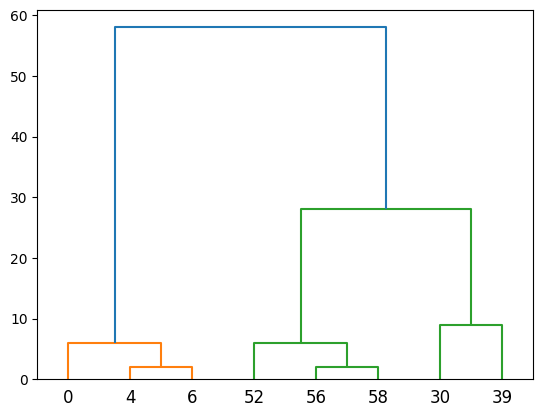

In [2]:
data = [0, 4, 6, 30, 39, 52, 56, 58]
Z = np.reshape(data, (len(data), 1))
dendrogram = sch.dendrogram(sch.linkage(Z, method='complete'), labels = data)

In [3]:
airports = ['BOS', 'NY', 'CHI', 'DEN', 'SF', 'SEA']
distance = [[0, 206, 963, 1949, 3095, 2979], 
            [206, 0, 802, 1771, 2934, 2815],
            [963, 802, 0, 966, 2142, 2013],
            [1949, 1771, 966, 0, 1235, 1307],
            [3095, 2934, 2142, 1235, 0, 808],
            [2979, 2815, 2013, 1307, 808,0]]

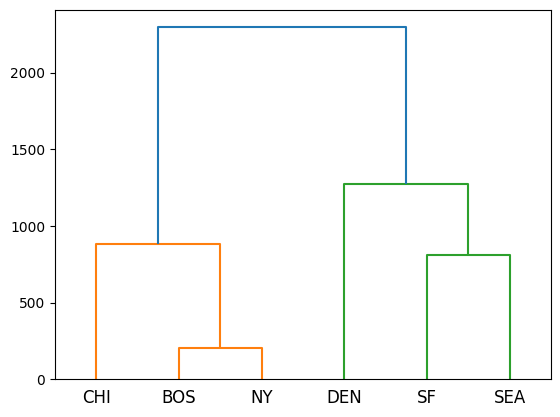

In [4]:
from scipy.spatial.distance import squareform
condensed_dist_matrix = squareform(distance)
dendrogram = sch.dendrogram(sch.linkage(condensed_dist_matrix, method='average'), labels = airports)

**k-means clustering**
- k is the number of clusters that you want
- If you don't have any idea about how many clusters there are this can be problematic
- If you know how many clusters there are this is a good choice as it is very fast


**k-means algorithm**
- Randomly choice samples as initial centroid
- while True:
- create k clusters by assigning each point to the closest cluster
- computer k new centroids by averaging the examples in each cluster
- if the centroids don't change exit

- Complexity of one iteration
- Compare each point with each centroid k*n
- Typically this converges quite quickly
- Most commonly used clustering algorithm as it is very fast

**Choosing k**
- Choosing wrong k can be problematic
- If k is non-sensical then your clustering will be non-sensical
- How do we choose k?
- Results can depend on the initial centroids
- k-means is non-deterministic
- If the initials centroids are poorly can take longer to converge or we can get a completely different answer

**Choosing k**
- Choose k with a priori knowledge of the application
- For example there are only 5 different types of bacteria
- Two types of people - DkiT and not
- Try different values of k and evaluate the quality of the results
- Run hierarchical clustering on a subset of the data
- Try and select good initial centroids distributed over the space
- Try multiple sets of randomly chosen centroids and choose the best result

**Mitigating dependence on initial centroids**
- Best = kmeans(points)
- for t in range(numTrials):
- C = kmeans(points)
- if dissimilarity(C) < dissimilarity(best)
- best = C
- return best
- Think of the centroid as the "centre of gravity of a cluster"

**Elbow method to find k**
- $SSE_1 = \sum_{i=0}^{n}dist(x_i -c_1)^2$
- $SSE = SSE_1 + \dots + SSE_n$

In [5]:
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib import pyplot as plt

In [6]:
df = pd.read_csv("income.csv")

In [7]:
df.head()

,Name,Age,Income
0,Rob,27,70000
1,Michael,29,90000
2,Mohen,29,61000
3,Ismail,28,60000
4,Kory,42,150000


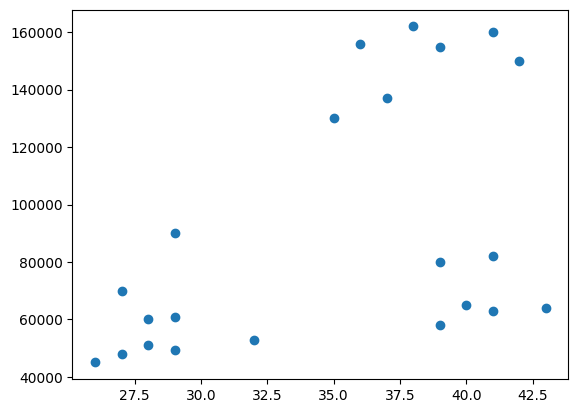

In [8]:
plt.scatter(df.Age, df.Income)

In [9]:
km = KMeans(n_clusters=3, n_init='auto')

In [10]:
km

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
y_predicted = km.fit_predict(df[['Age', 'Income']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
      dtype=int32)

In [12]:
df['cluster'] = y_predicted
df

,Name,Age,Income,cluster
0,Rob,27,70000,0
1,Michael,29,90000,0
2,Mohen,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1
5,Guatam,39,155000,1
6,David,41,160000,1
7,Andrea,38,162000,1
8,Brad,36,156000,1
9,Angelina,35,130000,2


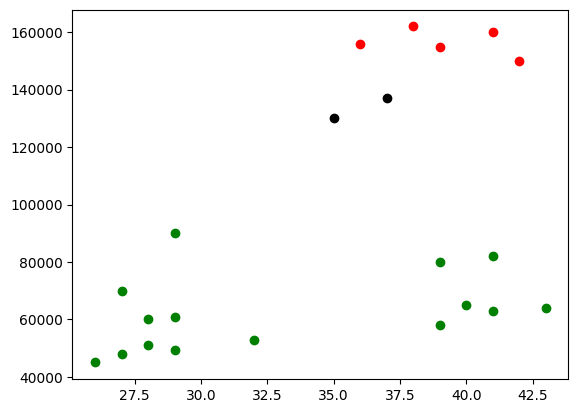

In [13]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1.Income, color='green')
plt.scatter(df2.Age, df2.Income, color='red')
plt.scatter(df3.Age, df3.Income, color='black')

- Problematic as features are not scaled
- Income 40,000 -> 160,000
- Age 25- 45
- Income will completely dominate unless scaled. If you don't scale the data you might as well forget about age as the scale for income is 1000 times bigger

In [14]:
scaler = MinMaxScaler()
scaler.fit(df[['Income']])
df.Income = scaler.transform(df['Income'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [15]:
df


,Name,Age,Income,cluster
0,Rob,27,0.213675,0
1,Michael,29,0.384615,0
2,Mohen,29,0.136752,0
3,Ismail,28,0.128205,0
4,Kory,42,0.897436,1
5,Guatam,39,0.940171,1
6,David,41,0.982906,1
7,Andrea,38,1.000000,1
8,Brad,36,0.948718,1
9,Angelina,35,0.726496,2


In [16]:
scaler.fit(df[['Age']])
df.Age = scaler.transform(df['Age'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [17]:
df

,Name,Age,Income,cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohen,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1
5,Guatam,0.764706,0.940171,1
6,David,0.882353,0.982906,1
7,Andrea,0.705882,1.000000,1
8,Brad,0.588235,0.948718,1
9,Angelina,0.529412,0.726496,2


In [18]:
km = KMeans(n_clusters=3, n_init='auto')
y_predicted = km.fit_predict(df[['Age', 'Income']])
df['cluster'] = y_predicted

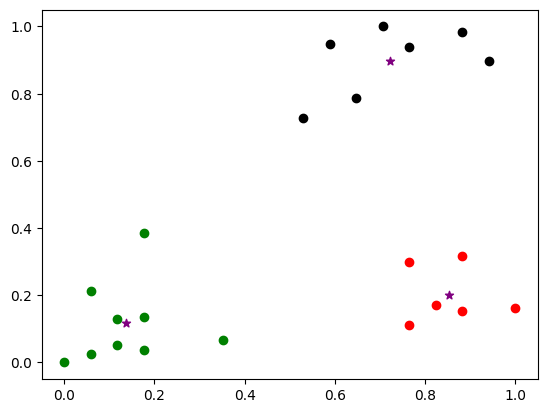

In [19]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]
plt.scatter(df1.Age, df1.Income, color='green')
plt.scatter(df2.Age, df2.Income, color='red')
plt.scatter(df3.Age, df3.Income, color='black')
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], color='purple', marker = '*', label='centroid')

In [20]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.85294118, 0.2022792 ],
       [0.72268908, 0.8974359 ]])

In [21]:
k_range = range(1, 10)
sse = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init='auto')
    km.fit(df[['Age', 'Income']])
    sse.append(km.inertia_)

In [22]:
sse

[5.434011511988179,
 2.091136388699078,
 0.4750783498553097,
 0.3687734076440591,
 0.2818479744366238,
 0.21066678488010523,
 0.20785157144249802,
 0.1397684499538816,
 0.11304517838728054]

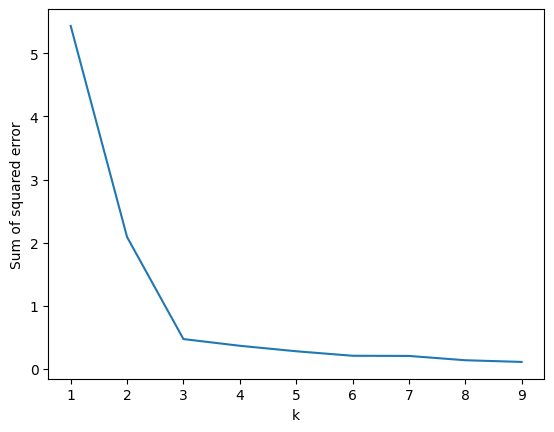

In [23]:
plt.xlabel('k')
plt.ylabel('Sum of squared error')
plt.plot(k_range, sse)

In [24]:
import pandas as pd
home_data = pd.read_csv('housing.csv', usecols=['longitude', 'latitude', 'median_house_value'])

In [25]:
home_data.head()

,longitude,latitude,median_house_value
0,-122.23,37.88,452600.0
1,-122.22,37.86,358500.0
2,-122.24,37.85,352100.0
3,-122.25,37.85,341300.0
4,-122.25,37.85,342200.0


<Axes: xlabel='longitude', ylabel='latitude'>

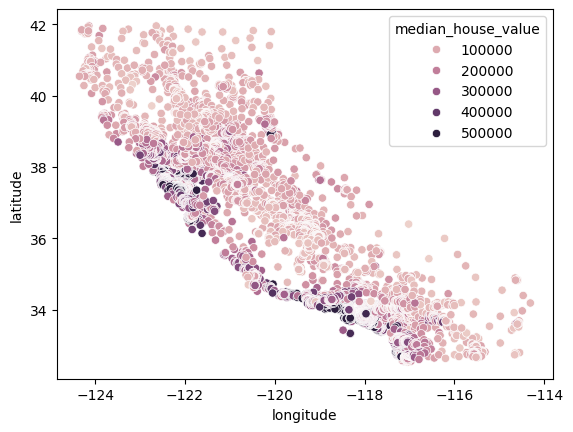

In [26]:
import seaborn as sns
sns.scatterplot(data = home_data, x='longitude', y='latitude', hue = 'median_house_value')

In [27]:
scaler = StandardScaler()
home_data_norm = home_data
scaler.fit(home_data[['longitude']])
home_data.longitude = scaler.transform(home_data['longitude'].values.reshape(-1, 1))


c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [28]:
scaler = StandardScaler()
scaler.fit(home_data[['latitude']])
home_data.latitude = scaler.transform(home_data['latitude'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [29]:
scaler = StandardScaler()
scaler.fit(home_data[['median_house_value']])
home_data.median_house_value = scaler.transform(home_data['median_house_value'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [30]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(home_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


<Axes: xlabel='longitude', ylabel='latitude'>

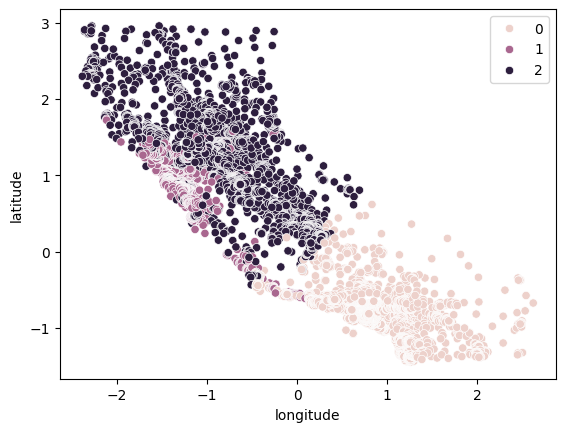

In [31]:
sns.scatterplot(data=home_data, x = 'longitude', y='latitude', hue = kmeans.labels_)

<Axes: ylabel='median_house_value'>

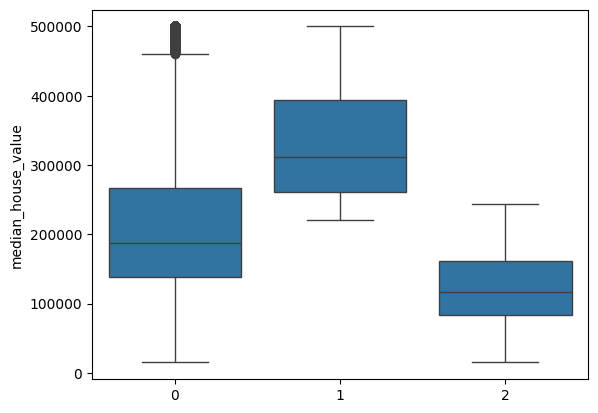

In [32]:
home_data = pd.read_csv('housing.csv', usecols=['longitude', 'latitude', 'median_house_value'])
sns.boxplot(x=kmeans.labels_, y = home_data['median_house_value'])

In [33]:
scaler = MinMaxScaler()
home_data_norm = home_data
scaler.fit(home_data[['longitude']])
home_data_norm.longitude = scaler.transform(home_data['longitude'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [34]:
scaler = MinMaxScaler()
home_data_norm = home_data
scaler.fit(home_data[['latitude']])
home_data_norm.latitude = scaler.transform(home_data['latitude'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [35]:
scaler = MinMaxScaler()
home_data_norm = home_data
scaler.fit(home_data[['median_house_value']])
home_data_norm.median_house_value = scaler.transform(home_data['median_house_value'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [36]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
kmeans.fit(home_data)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


<Axes: xlabel='longitude', ylabel='latitude'>

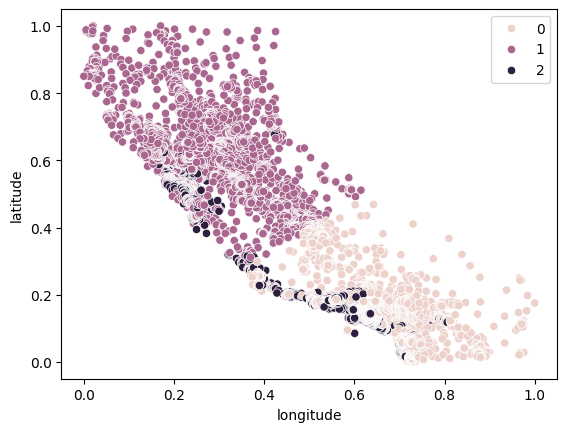

In [37]:
sns.scatterplot(data=home_data, x = 'longitude', y='latitude', hue = kmeans.labels_)

<Axes: ylabel='median_house_value'>

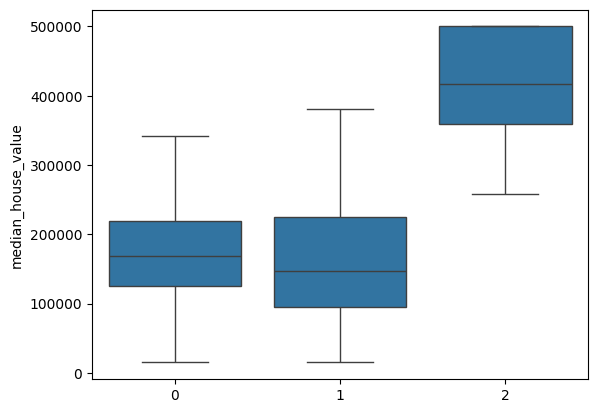

In [38]:
home_data = pd.read_csv('housing.csv', usecols=['longitude', 'latitude', 'median_house_value'])
sns.boxplot(x=kmeans.labels_, y = home_data['median_house_value'])

**DBSCAN**
- Density based spatial clustering of applications with noise
- Clusters are dense regions in the data space, separated by regions of lower density
- DBSCAN is based on an intuitive notion of "clusters" and "noise"
- The key idea os that for each point of a cluster, the neighbourhood of a given radius has to contain a given number of points
- Partitioning methods (k-means) and hierarchical clustering work for spherical shaped or convex clusters. In other words, they are suitable for compact and well separated clusters. They are severely impacted by the presense of noise and outliers
- Real like data can contain arbitrary shapes and can contain noise

**Parameters for DBSCAN**
- $/epsilon$ defines the neighbourhood around a point. If the distance between two point sif less than of equal to $/epsilon$ then they are considered neighbours. If the $/epsilon$ value is chosen too small then a large amount of our data will be considered outliers
- **MinPts** Minimum number of neighbours (data points) with $/epsilon$ radius. The larger the dataset, the larger the value of MinPts should be. As a general rule, MinPts can be derived from the number if dimensions D in the dataset, as MinPts >= D+1. The minimum value must be at least 3.
- In this algorithm there are 3 types of data points
- **Core point**: A point is a core point if it has at least MinPt within $\epsilon$
- **Border point**: A point which has fewer than MinPts with $\epsilon$ but is in the neighbourhood of a core point
- **Noise or outlier**: A point that is not a core point of a border point

**Steps for DBSCAN clustering algorithm**
- Find all the points with $\epsilon$ and identify the core points with greater than or equal to MinPts neighbours
- For each core point if it is not already assign to a cluster assign them to the same cluster as the core point
- Recursively find all connected points and assign to the same cluster as the core point
- Iterate through the remaining points. Add border points.
- Points that don't belong to any cluster are noise

**Pseudo code for DBSCAN**
- DBSCAN(dataset, eps, MinPts)
- C = 1
- for each unvisited point p in the dataset
- mark p as visisted
- find # neighbours for p
- neighbours N = find the neighbouring points of p
- if |N| >= MinPts
- Add p to C
- Add boundary points to C
- What is left is outliers

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

In [40]:
X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.5, random_state=0)

In [41]:
X

array([[ 1.03992529,  1.92991009],
       [-1.38609104,  7.48059603],
       [ 1.12538917,  4.96698028],
       [-1.05688956,  7.81833888],
       [ 1.4020041 ,  1.726729  ],
       [ 3.20722587,  0.36765575],
       [-1.76133611,  1.81716162],
       [ 1.34081536,  4.36827878],
       [-0.37881944,  8.33265721],
       [-0.80062564,  8.52294205],
       [-1.68146124,  2.80114893],
       [-2.43304923,  8.26748617],
       [ 1.19820169,  4.47062449],
       [-2.06457304,  7.05157615],
       [ 1.55515985,  0.12527811],
       [ 0.5408715 ,  4.0143625 ],
       [ 1.05374379,  4.49286859],
       [ 2.48368283,  0.57215086],
       [-1.14357242,  3.09602867],
       [-1.15330985,  2.32340978],
       [ 2.60509732,  1.22529553],
       [ 1.82346953,  1.1384044 ],
       [ 0.77468161,  4.91500986],
       [-1.91821859,  2.86268761],
       [-1.85305081,  2.65728761],
       [-0.30022483,  4.63059663],
       [ 1.7571105 ,  0.87138001],
       [ 0.65834704,  4.64200397],
       [-2.65468613,

In [42]:
y

array([1, 3, 0, 3, 1, 1, 2, 0, 3, 3, 2, 3, 0, 3, 1, 0, 0, 1, 2, 2, 1, 1,
       0, 2, 2, 0, 1, 0, 2, 0, 3, 3, 0, 3, 3, 3, 3, 3, 2, 1, 0, 2, 0, 0,
       2, 2, 3, 2, 3, 1, 2, 1, 3, 1, 1, 2, 3, 2, 3, 1, 3, 0, 3, 2, 2, 2,
       3, 1, 3, 2, 0, 2, 3, 2, 2, 3, 2, 0, 1, 3, 1, 0, 1, 1, 3, 0, 1, 0,
       3, 3, 0, 1, 3, 2, 2, 0, 1, 1, 0, 2, 3, 1, 3, 1, 0, 1, 1, 0, 3, 0,
       2, 2, 1, 3, 1, 0, 3, 1, 1, 0, 2, 1, 2, 1, 1, 1, 1, 2, 1, 2, 3, 2,
       2, 1, 3, 2, 2, 3, 0, 3, 3, 2, 0, 2, 0, 2, 3, 0, 3, 3, 3, 0, 3, 0,
       1, 2, 3, 2, 1, 0, 3, 0, 0, 1, 0, 2, 2, 0, 1, 0, 0, 3, 1, 0, 2, 3,
       1, 1, 0, 2, 1, 0, 2, 2, 0, 0, 0, 0, 1, 3, 0, 2, 0, 0, 2, 2, 2, 0,
       2, 3, 0, 2, 1, 2, 0, 3, 2, 3, 0, 3, 0, 2, 0, 0, 3, 2, 2, 1, 1, 0,
       3, 1, 1, 2, 1, 2, 0, 3, 3, 0, 0, 3, 0, 1, 2, 0, 1, 2, 3, 2, 1, 0,
       1, 3, 3, 3, 3, 2, 2, 3, 0, 2, 1, 0, 2, 2, 2, 1, 1, 3, 0, 0, 2, 1,
       3, 2, 0, 3, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0, 3, 3, 1, 1, 0, 1, 1, 1,
       3, 2, 3, 0, 1, 1, 3, 3, 3, 1, 1, 0, 3, 2])

In [43]:
db = DBSCAN(eps=0.8, min_samples=5).fit(X)

In [44]:
db.labels_

array([0, 1, 2, 1, 0, 0, 3, 2, 1, 1, 3, 1, 2, 1, 0, 2, 2, 0, 3, 3, 0, 0,
       2, 3, 3, 2, 0, 2, 3, 2, 1, 1, 2, 1, 1, 1, 1, 1, 3, 0, 2, 3, 2, 2,
       3, 3, 1, 3, 1, 0, 3, 0, 1, 0, 0, 3, 1, 3, 1, 0, 1, 2, 1, 3, 3, 3,
       1, 0, 1, 3, 2, 3, 1, 3, 3, 1, 3, 2, 0, 1, 0, 2, 0, 0, 1, 2, 0, 2,
       1, 1, 2, 0, 1, 3, 3, 2, 0, 0, 2, 3, 1, 0, 1, 0, 2, 0, 0, 2, 1, 2,
       3, 3, 0, 1, 0, 2, 1, 0, 0, 2, 3, 0, 3, 0, 0, 0, 0, 3, 0, 3, 1, 3,
       3, 0, 1, 3, 3, 1, 2, 1, 1, 3, 2, 3, 2, 3, 1, 2, 1, 1, 1, 2, 1, 2,
       0, 3, 1, 3, 0, 2, 1, 2, 2, 0, 2, 3, 3, 2, 0, 2, 2, 1, 0, 2, 3, 1,
       0, 0, 2, 3, 0, 2, 3, 3, 2, 2, 2, 2, 0, 1, 2, 3, 2, 2, 3, 3, 3, 2,
       3, 1, 2, 3, 0, 3, 2, 1, 3, 1, 2, 1, 2, 3, 2, 2, 1, 3, 3, 0, 0, 2,
       1, 0, 0, 3, 0, 3, 2, 1, 1, 2, 2, 1, 2, 0, 3, 2, 0, 3, 1, 3, 0, 2,
       0, 1, 1, 1, 1, 3, 3, 1, 2, 3, 0, 2, 3, 3, 3, 0, 0, 1, 2, 2, 3, 0,
       1, 3, 2, 1, 2, 0, 0, 3, 3, 2, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0,
       1, 3, 1, 2, 0, 0, 1, 1, 1, 0, 0, 2, 1, 3])

In [45]:
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)


In [46]:
core_samples_mask[db.core_sample_indices_] = True


In [47]:
labels = db.labels_

In [48]:
#Number of clusters in the labels, ignoring any noise if present
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

In [49]:
n_clusters

4

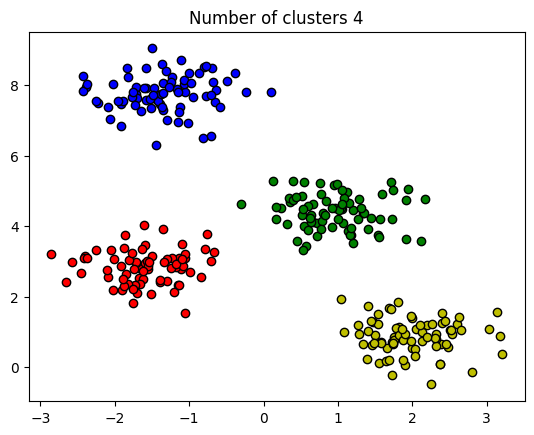

In [50]:
#Plot result
#Black to indicate noise
unique_labels = set(labels)
colours = ['y', 'b', 'g', 'r', 'c']
for k, col in zip(unique_labels, colours):
    if k == -1:
        #Black is the colour for noise
        col = 'k'
        
    class_member_mask = (labels == k)
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:,0], xy[:, 1], 'o', markerfacecolor=col, markeredgecolor='k', markersize = 6)
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:,0], xy[:, 1], 'x', markerfacecolor=col, markeredgecolor='k', markersize = 6)
    
plt.title(f"Number of clusters {n_clusters}")
plt.show()
    

**Evaluation metrics for DBSCAN**
- Sihouette score is in the range from -1 to 1. A score 1 indicates that we have compact clusters. The worst value is -1. Values near indicate overlapping clusters
- Adjusted Rand Score is in the range from 0 to 1. More than 0.9 denotes an excellent cluster, above 0.8 is good. Less than 0.5 is poor.

In [51]:
sc = metrics.silhouette_score(X, labels)
sc

0.7356713838266389

In [52]:
from sklearn.metrics import adjusted_rand_score
ars = adjusted_rand_score(y, labels)
ars

1.0

In [53]:
# Cluster California housing data using DBSCAN
import pandas as pd
home_data = pd.read_csv('housing.csv', usecols=['longitude', 'latitude', 'median_house_value'])

In [54]:
scaler = MinMaxScaler()
home_data_norm = home_data
scaler.fit(home_data[['longitude']])
home_data_norm.longitude = scaler.transform(home_data['longitude'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [55]:
scaler = MinMaxScaler()
home_data_norm = home_data
scaler.fit(home_data[['latitude']])
home_data_norm.latitude = scaler.transform(home_data['latitude'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [56]:
scaler = MinMaxScaler()
home_data_norm = home_data
scaler.fit(home_data[['median_house_value']])
home_data_norm.median_house_value = scaler.transform(home_data['median_house_value'].values.reshape(-1, 1))

c:\Users\johnl\dev\DAV\DAV_26\MLR\mlr_env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [91]:
db = DBSCAN(eps=0.06, min_samples=45).fit(home_data_norm)

In [92]:
db_set = set(db.labels_)
db_set

{np.int64(-1), np.int64(0), np.int64(1), np.int64(2)}

In [93]:
sc = metrics.silhouette_score(home_data_norm, db.labels_)
sc

-0.19533769460161765

In [94]:
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)

In [95]:
core_samples_mask[db.core_sample_indices_] = True

       longitude  latitude  median_house_value
0       0.211155  0.567481            0.902266
1       0.212151  0.565356            0.708247
2       0.210159  0.564293            0.695051
3       0.209163  0.564293            0.672783
4       0.209163  0.564293            0.674638
...          ...       ...                 ...
20635   0.324701  0.737513            0.130105
20636   0.312749  0.738576            0.128043
20637   0.311753  0.732200            0.159383
20638   0.301793  0.732200            0.143713
20639   0.309761  0.725824            0.153403

[19066 rows x 3 columns]
      longitude  latitude  median_house_value
2538   0.017928  0.877790            0.092785
2539   0.018924  0.877790            0.135053
2540   0.018924  0.876727            0.127630
2541   0.017928  0.877790            0.124744
2542   0.017928  0.877790            0.097940
...         ...       ...                 ...
2652   0.031873  0.840595            0.116084
2653   0.008964  0.854410            0.198

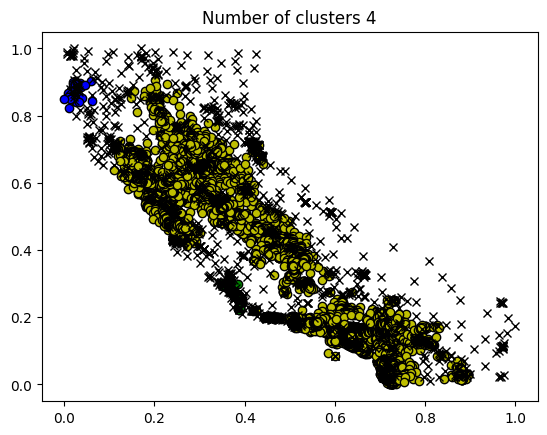

In [96]:
#Plot result
#Black to indicate noise
unique_labels = set(db.labels_)
colours = ['y', 'b', 'g', 'r']
for k, col in zip(unique_labels, colours):
    if k == -1:
        #Black is the colour for noise
        col = 'k'
        
    class_member_mask = (db.labels_ == k)
    xy = home_data_norm[class_member_mask & core_samples_mask]
    print(xy)
    plt.plot(xy['longitude'], xy['latitude'], 'o', markerfacecolor=col, markeredgecolor='k', markersize = 6)
    xy = home_data_norm[class_member_mask & ~core_samples_mask]
    plt.plot(xy['longitude'], xy['latitude'], 'x', markerfacecolor=col, markeredgecolor='k', markersize = 6)
    
plt.title(f"Number of clusters {n_clusters}")
plt.show()

**Difference between DBSCAN and k-means**
|DBSCAN| k-means|
|---|---|
|In DBSCAN we don't need to specify the number of clusters|k-means is very sensitive to the number of clusters so k needs to be specified|
| Cluster formed in DBSCAN can be any arbitrary shape| Cluster formed in k-means are spherical or convex in shape|
|DBSCAN can work well with datasets that have noise and outliers|k-means does not work well with outliers. Outliers can skew the clusters in k-means massively|
|In DBSCAN two parameters are required for training the model| In k-means we only need one parameter, k|

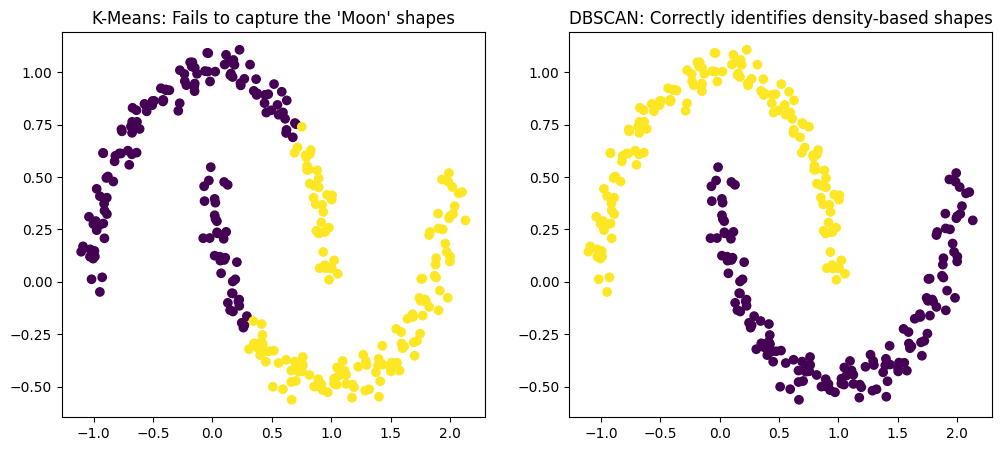

In [97]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN

# Generate "Moon" shaped data
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Run K-Means
km = KMeans(n_clusters=2, random_state=42).fit(X)

# Run DBSCAN
db = DBSCAN(eps=0.2, min_samples=5).fit(X)

# Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.scatter(X[:, 0], X[:, 1], c=km.labels_, cmap='viridis')
ax1.set_title("K-Means: Fails to capture the 'Moon' shapes")

ax2.scatter(X[:, 0], X[:, 1], c=db.labels_, cmap='viridis')
ax2.set_title("DBSCAN: Correctly identifies density-based shapes")
plt.show()